In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
 
# ─────────────────────────────────────────────
# Step 1: Build the mesh
# ─────────────────────────────────────────────
 
def build_mesh(m=5, n=5, x_min=0, x_max=1, y_min=0, y_max=1):
    """
    Build a structured 2D mesh with m rows and n columns of NODES.
    
    This gives (m-1)×(n-1) quadrilateral elements.
    
    Returns
    -------
    X, Y  : 2D arrays of shape (m, n) — coordinates of each node
    xs    : 1D x-node positions
    ys    : 1D y-node positions
    hx, hy: mesh spacings
    """
    xs = np.linspace(x_min, x_max, n)   # n nodes along x
    ys = np.linspace(y_min, y_max, m)   # m nodes along y
    hx = xs[1] - xs[0]                  # uniform spacing in x
    hy = ys[1] - ys[0]                  # uniform spacing in y
    X, Y = np.meshgrid(xs, ys)          # X[i,j] = xs[j], Y[i,j] = ys[i]
    return X, Y, xs, ys, hx, hy
 
m, n = 5, 5
X, Y, xs, ys, hx, hy = build_mesh(m, n)
 
print("=" * 60)
print("STEP 1: Mesh construction")
print("=" * 60)
print(f"  Nodes: {m} rows × {n} cols = {m*n} total nodes")
print(f"  Elements: {m-1} × {n-1} = {(m-1)*(n-1)} quadrilateral cells")
print(f"  x-spacing hx = {hx:.4f},  y-spacing hy = {hy:.4f}")
print(f"  x nodes: {xs}")
print(f"  y nodes: {ys}")
print()


STEP 1: Mesh construction
  Nodes: 5 rows × 5 cols = 25 total nodes
  Elements: 4 × 4 = 16 quadrilateral cells
  x-spacing hx = 0.2500,  y-spacing hy = 0.2500
  x nodes: [0.   0.25 0.5  0.75 1.  ]
  y nodes: [0.   0.25 0.5  0.75 1.  ]



In [2]:
# ─────────────────────────────────────────────
# Step 2: 1D hat function
# ─────────────────────────────────────────────
 
def hat_1d(x, xi, h):
    """
    1D hat (tent) function centered at xi with radius h.
 
        phi(x) = max(0,  1 - |x - xi| / h)
 
    This is piecewise linear, continuous, and has support [xi-h, xi+h].
    Its derivative is ±1/h on each side — so grad is in L².
    """
    return np.maximum(0.0, 1.0 - np.abs(x - xi) / h)
 
print("=" * 60)
print("STEP 2: 1D hat function")
print("=" * 60)
print("  phi_i(x) = max(0, 1 - |x - x_i| / h)")
print("  Support: [x_i - h, x_i + h]")
print("  Gradient: +1/h for x < x_i, -1/h for x > x_i (piecewise constant)")
print()


STEP 2: 1D hat function
  phi_i(x) = max(0, 1 - |x - x_i| / h)
  Support: [x_i - h, x_i + h]
  Gradient: +1/h for x < x_i, -1/h for x > x_i (piecewise constant)



In [3]:
# ─────────────────────────────────────────────
# Step 3: 2D bilinear basis function (tensor product)
# ─────────────────────────────────────────────
 
def basis_2d(x, y, xi, yj, hx, hy):
    """
    Bilinear hat basis function φ_{i,j}(x, y) = φ_i(x) · φ_j(y).
 
    This is the tensor product of two 1D hat functions.
    Support: [xi-hx, xi+hx] × [yj-hy, yj+hy]  — a square "tent"
    Shape: a pyramid over the support square.
 
    Kronecker property:
      φ_{i,j}(x_k, y_l) = δ_{ik} · δ_{jl}
    because hat_1d(x_k, xi, hx) = 1 if k==i else 0.
 
    H¹ membership:
      - L²: bounded, compact support → integrable
      - ∂φ/∂x = φ_j(y) · dφ_i/dx  (piecewise constant in x, hat in y) → L²
      - ∂φ/∂y = φ_i(x) · dφ_j/dy  → L²
    """
    return hat_1d(x, xi, hx) * hat_1d(y, yj, hy)
 
print("=" * 60)
print("STEP 3: 2D bilinear basis function")
print("=" * 60)
print("  phi_{i,j}(x,y) = phi_i(x) · phi_j(y)   [tensor product]")
print("  This is BILINEAR (linear in x, linear in y separately),")
print("  NOT linear over the whole element — that's a key FEM detail.")
print()


STEP 3: 2D bilinear basis function
  phi_{i,j}(x,y) = phi_i(x) · phi_j(y)   [tensor product]
  This is BILINEAR (linear in x, linear in y separately),
  NOT linear over the whole element — that's a key FEM detail.



In [4]:
# ─────────────────────────────────────────────
# Step 4: Verify the Kronecker delta property
# ─────────────────────────────────────────────
 
print("=" * 60)
print("STEP 4: Verify Kronecker delta property")
print("=" * 60)
print("  Evaluating ALL basis functions at ALL mesh nodes...")
print()
 
all_pass = True
for i in range(m):       # row index (y direction)
    for j in range(n):   # col index (x direction)
        xi, yj = xs[j], ys[i]  # center of this basis function
        
        for k in range(m):
            for l in range(n):
                xk, yl = xs[l], ys[k]
                val = basis_2d(xk, yl, xi, yj, hx, hy)
                
                expected = 1.0 if (i == k and j == l) else 0.0
                if not np.isclose(val, expected):
                    print(f"  FAIL: phi_({i},{j})({k},{l}) = {val:.4f}, expected {expected}")
                    all_pass = False
 
if all_pass:
    print("  ✓ All basis functions satisfy phi_{i,j}(x_k, y_l) = δ_{ik}·δ_{jl}")
print()


STEP 4: Verify Kronecker delta property
  Evaluating ALL basis functions at ALL mesh nodes...

  ✓ All basis functions satisfy phi_{i,j}(x_k, y_l) = δ_{ik}·δ_{jl}



In [5]:
# ─────────────────────────────────────────────
# Step 5: Verify partition of unity
# ─────────────────────────────────────────────
 
print("=" * 60)
print("STEP 5: Partition of unity")
print("=" * 60)
print("  A good basis should satisfy: Σ_{i,j} φ_{i,j}(x,y) = 1 everywhere")
print("  (This ensures constant functions are reproduced exactly)")
print()
 
# Check at a random interior point
test_pts = [(0.3, 0.4), (0.5, 0.5), (0.72, 0.18), (0.1, 0.9)]
for (tx, ty) in test_pts:
    total = sum(
        basis_2d(tx, ty, xs[j], ys[i], hx, hy)
        for i in range(m) for j in range(n)
    )
    print(f"  Σ φ_{{i,j}}({tx}, {ty}) = {total:.6f}  {'✓' if np.isclose(total, 1.0) else '✗'}")
print()


STEP 5: Partition of unity
  A good basis should satisfy: Σ_{i,j} φ_{i,j}(x,y) = 1 everywhere
  (This ensures constant functions are reproduced exactly)

  Σ φ_{i,j}(0.3, 0.4) = 1.000000  ✓
  Σ φ_{i,j}(0.5, 0.5) = 1.000000  ✓
  Σ φ_{i,j}(0.72, 0.18) = 1.000000  ✓
  Σ φ_{i,j}(0.1, 0.9) = 1.000000  ✓



In [6]:
# ─────────────────────────────────────────────
# Step 6: Build the interpolant for a test function
# ─────────────────────────────────────────────
 
print("=" * 60)
print("STEP 6: Build the interpolant")
print("=" * 60)
print()
print("  The interpolant is:  u_h(x,y) = Σ_{i,j} u_{i,j} · φ_{i,j}(x,y)")
print()
print("  Here u_{i,j} = u(x_i, y_j) are just nodal samples of the true function.")
print("  No matrix inversion needed for the interpolant itself!")
print("  (The matrix solve comes when you're approximating a PDE solution.)")
print()
 
# True function to interpolate
def u_true(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)
 
# Sample at nodes
U_nodes = u_true(X, Y)  # shape (m, n)
 
print(f"  True function: u(x,y) = sin(πx)·sin(πy)")
print(f"  Nodal values U_nodes:\n")
print(np.array2string(U_nodes, precision=4, suppress_small=True))
print()
 
# Evaluate interpolant on a fine grid
N_fine = 80
x_fine = np.linspace(0, 1, N_fine)
y_fine = np.linspace(0, 1, N_fine)
Xf, Yf = np.meshgrid(x_fine, y_fine)
 
U_interp = np.zeros_like(Xf)
for i in range(m):
    for j in range(n):
        U_interp += U_nodes[i, j] * basis_2d(Xf, Yf, xs[j], ys[i], hx, hy)
 
U_exact = u_true(Xf, Yf)
error = np.max(np.abs(U_interp - U_exact))
print(f"  Max interpolation error: {error:.6f}")
print(f"  (Should be O(h²) = O({hx**2:.4f}) for bilinear elements on smooth functions)")
print()


STEP 6: Build the interpolant

  The interpolant is:  u_h(x,y) = Σ_{i,j} u_{i,j} · φ_{i,j}(x,y)

  Here u_{i,j} = u(x_i, y_j) are just nodal samples of the true function.
  No matrix inversion needed for the interpolant itself!
  (The matrix solve comes when you're approximating a PDE solution.)

  True function: u(x,y) = sin(πx)·sin(πy)
  Nodal values U_nodes:

[[0.     0.     0.     0.     0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.7071 1.     0.7071 0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.     0.     0.     0.    ]]

  Max interpolation error: 0.126249
  (Should be O(h²) = O(0.0625) for bilinear elements on smooth functions)



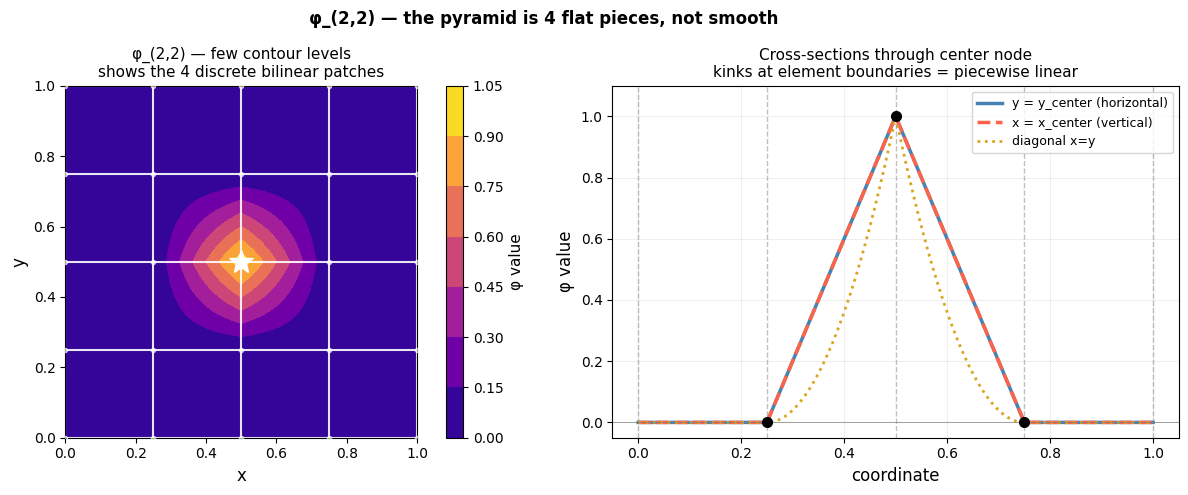

In [15]:
def plot_basis_function_2d(i_center, j_center, m=5, n=5):

    X, Y, xs, ys, hx, hy = build_mesh(m, n)

    N_fine = 200
    x_fine = np.linspace(0, 1, N_fine)
    y_fine = np.linspace(0, 1, N_fine)
    Xf, Yf = np.meshgrid(x_fine, y_fine)

    Z = basis_2d(Xf, Yf, xs[j_center], ys[i_center], hx, hy)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: few levels so you can see the discrete planes ──
    ax = axes[0]
    cf = ax.contourf(Xf, Yf, Z, levels=8, cmap='plasma')   # <-- key change
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label('φ value', fontsize=11)

    # thick element boundary lines — these are where the planes meet
    for xi in xs:
        ax.axvline(xi, color='white', linewidth=1.5, alpha=0.9, linestyle='-')
    for yi in ys:
        ax.axhline(yi, color='white', linewidth=1.5, alpha=0.9, linestyle='-')

    for i in range(m):
        for j in range(n):
            if i == i_center and j == j_center:
                ax.plot(xs[j], ys[i], 'w*', markersize=18, zorder=5)
            else:
                ax.plot(xs[j], ys[i], 'w.', markersize=6, alpha=0.6, zorder=4)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'φ_({i_center},{j_center}) — few contour levels\n'
                 f'shows the 4 discrete bilinear patches', fontsize=11)
    ax.set_aspect('equal')

    # ── Right: cross-sections through the center node ──
    ax2 = axes[1]

    # horizontal slice at y = y_center
    phi_along_x = basis_2d(x_fine, ys[i_center], xs[j_center], ys[i_center], hx, hy)
    # vertical slice at x = x_center
    phi_along_y = basis_2d(xs[j_center], y_fine, xs[j_center], ys[i_center], hx, hy)
    # diagonal slice y=x (only meaningful if square mesh)
    diag = np.linspace(0, 1, N_fine)
    phi_diag = basis_2d(diag, diag, xs[j_center], ys[i_center], hx, hy)

    ax2.plot(x_fine, phi_along_x, color='steelblue', lw=2.5, label='y = y_center (horizontal)')
    ax2.plot(y_fine, phi_along_y, color='tomato',    lw=2.5, label='x = x_center (vertical)', ls='--')
    ax2.plot(diag,   phi_diag,    color='goldenrod',  lw=2,   label='diagonal x=y', ls=':')

    # mark where the element boundaries are
    for xi in xs:
        ax2.axvline(xi, color='gray', linewidth=1, alpha=0.5, linestyle='--')
    ax2.axhline(0, color='gray', linewidth=0.5)

    # annotate the kinks — these are where one linear piece meets the next
    kink_xs = [xs[j_center - 1], xs[j_center], xs[j_center + 1]] \
               if 0 < j_center < n-1 else [xs[j_center]]
    for kx in kink_xs:
        val = basis_2d(kx, ys[i_center], xs[j_center], ys[i_center], hx, hy)
        ax2.plot(kx, val, 'ko', markersize=7, zorder=5)

    ax2.set_xlabel('coordinate', fontsize=12)
    ax2.set_ylabel('φ value', fontsize=12)
    ax2.set_title('Cross-sections through center node\n'
                  'kinks at element boundaries = piecewise linear', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.set_ylim(-0.05, 1.1)

    plt.suptitle(f'φ_({i_center},{j_center}) — the pyramid is 4 flat pieces, not smooth',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


i_node = 2
j_node = 2
plot_basis_function_2d(i_node, j_node)

In [21]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

def assemble_stiffness(m, n, xs, ys, hx, hy):
    """
    Assemble the global stiffness matrix A by looping over
    each quad element and scattering the 4x4 local matrix.
    """
    n_nodes = m * n
    A = np.zeros((n_nodes, n_nodes))

    # local stiffness matrix for a square cell of side h
    # rows/cols: bottom-left, bottom-right, top-left, top-right
    Ke = (1/6) * np.array([
        [ 4, -1, -1, -2],
        [-1,  4, -2, -1],
        [-1, -2,  4, -1],
        [-2, -1, -1,  4]
    ])

    for r in range(m - 1):       # cell row
        for c in range(n - 1):   # cell col

            # global node indices of this cell's 4 corners (flattened)
            #   top-left     top-right
            #   bottom-left  bottom-right
            bl = (r    ) * n + (c    )   # bottom-left
            br = (r    ) * n + (c + 1)   # bottom-right
            tl = (r + 1) * n + (c    )   # top-left
            tr = (r + 1) * n + (c + 1)   # top-right

            local_to_global = [bl, br, tl, tr]

            # scatter: add local contribution into global matrix
            for p in range(4):
                for q in range(4):
                    I = local_to_global[p]
                    J = local_to_global[q]
                    A[I, J] += Ke[p, q]

    return A


def assemble_load_gauss(m, n, xs, ys, hx, hy, f_func):
    """
    Assemble load vector using 2x2 Gauss quadrature per element.
    
    On the reference element [-1,1]x[-1,1], the 2x2 Gauss points are
    at ±1/sqrt(3) with weight 1 each. This integrates degree-3
    polynomials exactly — much better than corner lumping.
    """
    n_nodes = m * n
    f_vec = np.zeros(n_nodes)

    # Gauss points and weights on [-1, 1]
    gp = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
    gw = np.array([1.0, 1.0])

    for r in range(m - 1):
        for c in range(n - 1):

            x0, x1 = xs[c], xs[c+1]
            y0, y1 = ys[r], ys[r+1]

            bl = r * n + c
            br = r * n + (c + 1)
            tl = (r + 1) * n + c
            tr = (r + 1) * n + (c + 1)

            local_to_global = [bl, br, tl, tr]

            for gi, xi_g in enumerate(gp):
                for gj, eta_g in enumerate(gp):

                    # map Gauss point from [-1,1]^2 to physical cell
                    x_phys = 0.5*(x0 + x1) + 0.5*hx*xi_g
                    y_phys = 0.5*(y0 + y1) + 0.5*hy*eta_g

                    # jacobian of the mapping
                    jac = (hx/2) * (hy/2)

                    # evaluate f at this Gauss point
                    f_val = f_func(x_phys, y_phys)

                    # bilinear shape functions at this Gauss point
                    # on reference element [-1,1]^2:
                    #   N_bl = (1-xi)(1-eta)/4
                    #   N_br = (1+xi)(1-eta)/4
                    #   N_tl = (1-xi)(1+eta)/4
                    #   N_tr = (1+xi)(1+eta)/4
                    xi, eta = xi_g, eta_g
                    N = np.array([
                        (1 - xi)*(1 - eta)/4,   # bl
                        (1 + xi)*(1 - eta)/4,   # br
                        (1 - xi)*(1 + eta)/4,   # tl
                        (1 + xi)*(1 + eta)/4,   # tr
                    ])

                    weight = gw[gi] * gw[gj]

                    for p in range(4):
                        f_vec[local_to_global[p]] += weight * N[p] * f_val * jac

    return f_vec


# ── re-run with Gauss quadrature ──────────────────────────────

A        = assemble_stiffness(m, n, xs, ys, hx, hy)
f_vec    = assemble_load_gauss(m, n, xs, ys, hx, hy, f_func)
A, f_vec = apply_dirichlet(A, f_vec, m, n)

u_flat   = spsolve(sparse.csr_matrix(A), f_vec)
U_sol    = u_flat.reshape(m, n)

print("Solved nodal values u_h (Gauss quadrature):")
print(np.array2string(U_sol, precision=4, suppress_small=True))
print()
print("Exact values:")
print(np.array2string(u_exact(X, Y), precision=4, suppress_small=True))
print()
print(f"Max error: {np.max(np.abs(U_sol - u_exact(X,Y))):.6f}")

def apply_dirichlet(A, f_vec, m, n):
    """
    Enforce u=0 on the boundary by zeroing out boundary rows/cols
    and putting 1 on the diagonal.
    
    This is the simplest approach — it modifies A and f in place.
    """
    def is_boundary(k):
        i, j = divmod(k, n)
        return i == 0 or i == m-1 or j == 0 or j == n-1

    n_nodes = m * n
    for k in range(n_nodes):
        if is_boundary(k):
            A[k, :] = 0
            A[:, k] = 0
            A[k, k] = 1
            f_vec[k] = 0

    return A, f_vec


# ── put it all together ──────────────────────────────────────

m, n = 5, 5
X, Y, xs, ys, hx, hy = build_mesh(m, n)

# your forcing function — swap this out for whatever f you're given
def f_func(x, y):
    return 2 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)

# exact solution for this f is sin(πx)sin(πy)
def u_exact(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

A      = assemble_stiffness(m, n, xs, ys, hx, hy)
f_vec  = assemble_load(m, n, xs, ys, hx, hy, f_func)
A, f_vec = apply_dirichlet(A, f_vec, m, n)

u_flat = spsolve(sparse.csr_matrix(A), f_vec)
U_sol  = u_flat.reshape(m, n)

print("Solved nodal values u_h:")
print(np.array2string(U_sol, precision=4, suppress_small=True))
print()
print("Exact values u(x,y) = sin(πx)sin(πy):")
print(np.array2string(u_exact(X, Y), precision=4, suppress_small=True))

Solved nodal values u_h (Gauss quadrature):
[[0.     0.     0.     0.     0.    ]
 [0.     0.5265 0.7446 0.5265 0.    ]
 [0.     0.7446 1.053  0.7446 0.    ]
 [0.     0.5265 0.7446 0.5265 0.    ]
 [0.     0.     0.     0.     0.    ]]

Exact values:
[[0.     0.     0.     0.     0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.7071 1.     0.7071 0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.     0.     0.     0.    ]]

Max error: 0.052962
Solved nodal values u_h:
[[0.     0.     0.     0.     0.    ]
 [0.     0.5835 0.8252 0.5835 0.    ]
 [0.     0.8252 1.167  0.8252 0.    ]
 [0.     0.5835 0.8252 0.5835 0.    ]
 [0.     0.     0.     0.     0.    ]]

Exact values u(x,y) = sin(πx)sin(πy):
[[0.     0.     0.     0.     0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.7071 1.     0.7071 0.    ]
 [0.     0.5    0.7071 0.5    0.    ]
 [0.     0.     0.     0.     0.    ]]


    m         h      L2 error      H1 error   L2 rate   H1 rate
-----------------------------------------------------------------
    5    0.2500      2.55e-02      5.00e-01       nan       nan
    9    0.1250      6.41e-03      2.51e-01     1.993     0.992
   17    0.0625      1.61e-03      1.26e-01     1.998     0.998
   33    0.0312      4.02e-04      6.29e-02     1.999     0.999
   65    0.0156      1.00e-04      3.15e-02     2.000     1.000


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/fem_convergence.png'

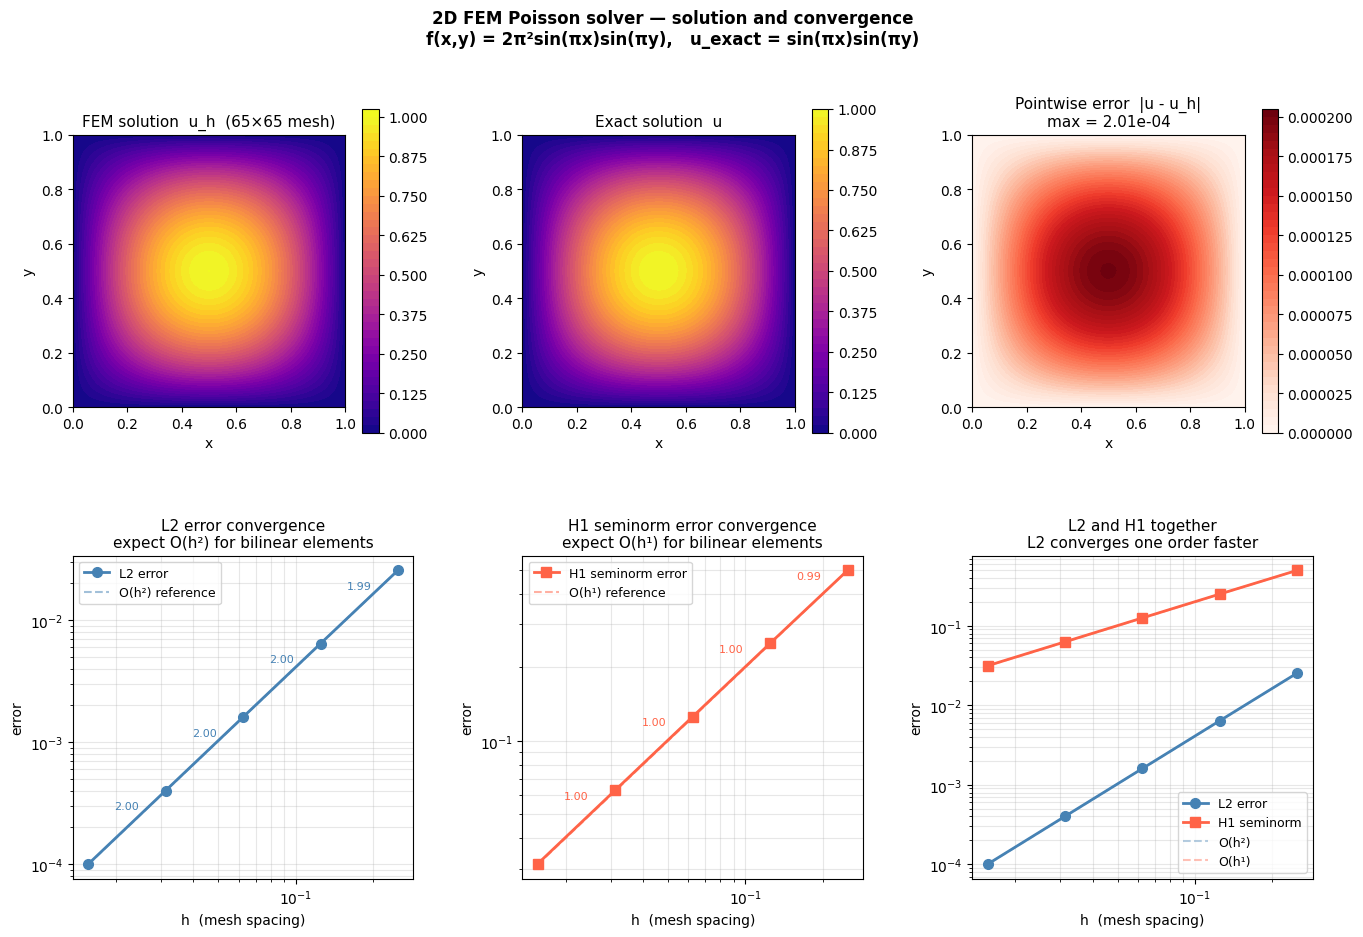

In [ ]:
"""
FEM 2D Poisson solver with L2 and H1 convergence study
=======================================================

Change f_func and u_exact below to whatever problem you want.
The script runs the solver on meshes from 5x5 up to 65x65,
plots the solution on the finest mesh, and plots convergence
of the L2 and H1 errors against mesh size h.
"""

import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────
# CHANGE THESE — your forcing function and exact solution
# ─────────────────────────────────────────────────────────────

def f_func(x, y):
    """Right hand side f(x,y) in -Delta u = f."""
    return 2 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)

def u_exact(x, y):
    """True solution — used only for error computation."""
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def grad_u_exact(x, y):
    """Gradient of exact solution — needed for H1 error."""
    dudx = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
    dudy = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    return dudx, dudy

# other examples you can swap in:
#
# constant load:
#   f_func   = lambda x,y: 1.0
#   u_exact  = None   (no closed form — set compute_errors=False)
#
# double sine:
#   f_func   = lambda x,y: (np.pi**2 + 4*np.pi**2)*np.sin(np.pi*x)*np.sin(2*np.pi*y)
#   u_exact  = lambda x,y: np.sin(np.pi*x)*np.sin(2*np.pi*y)
#   grad ... = lambda x,y: (np.pi*np.cos(np.pi*x)*np.sin(2*np.pi*y),
#                           2*np.pi*np.sin(np.pi*x)*np.cos(2*np.pi*y))

# ─────────────────────────────────────────────────────────────
# Mesh
# ─────────────────────────────────────────────────────────────

def build_mesh(m, n):
    xs = np.linspace(0, 1, n)
    ys = np.linspace(0, 1, m)
    hx = xs[1] - xs[0]
    hy = ys[1] - ys[0]
    X, Y = np.meshgrid(xs, ys)
    return X, Y, xs, ys, hx, hy

# ─────────────────────────────────────────────────────────────
# Stiffness matrix — local Ke analytically derived for square cell
# ─────────────────────────────────────────────────────────────

def assemble_stiffness(m, n, hx, hy):
    n_nodes = m * n
    rows, cols, vals = [], [], []

    Ke = (1.0/6.0) * np.array([
        [ 4, -1, -1, -2],
        [-1,  4, -2, -1],
        [-1, -2,  4, -1],
        [-2, -1, -1,  4]
    ])

    for r in range(m - 1):
        for c in range(n - 1):
            bl = r       * n + c
            br = r       * n + (c + 1)
            tl = (r + 1) * n + c
            tr = (r + 1) * n + (c + 1)
            lg = [bl, br, tl, tr]

            for p in range(4):
                for q in range(4):
                    rows.append(lg[p])
                    cols.append(lg[q])
                    vals.append(Ke[p, q])

    return sparse.csr_matrix((vals, (rows, cols)), shape=(n_nodes, n_nodes))

# ─────────────────────────────────────────────────────────────
# Load vector — 2x2 Gauss quadrature per element
# ─────────────────────────────────────────────────────────────

def assemble_load(m, n, xs, ys, hx, hy, f):
    n_nodes = m * n
    f_vec = np.zeros(n_nodes)

    gp = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
    gw = np.array([1.0, 1.0])

    for r in range(m - 1):
        for c in range(n - 1):
            x0, x1 = xs[c], xs[c+1]
            y0, y1 = ys[r], ys[r+1]
            bl = r       * n + c
            br = r       * n + (c + 1)
            tl = (r + 1) * n + c
            tr = (r + 1) * n + (c + 1)
            lg = [bl, br, tl, tr]

            for gi in range(2):
                for gj in range(2):
                    xi  = gp[gi];  eta = gp[gj]
                    xp  = 0.5*(x0+x1) + 0.5*hx*xi
                    yp  = 0.5*(y0+y1) + 0.5*hy*eta
                    jac = (hx/2)*(hy/2)
                    fv  = f(xp, yp)
                    w   = gw[gi]*gw[gj]

                    N = np.array([
                        (1-xi)*(1-eta)/4,
                        (1+xi)*(1-eta)/4,
                        (1-xi)*(1+eta)/4,
                        (1+xi)*(1+eta)/4,
                    ])
                    for p in range(4):
                        f_vec[lg[p]] += w * N[p] * fv * jac

    return f_vec

# ─────────────────────────────────────────────────────────────
# Dirichlet BC — zero on all boundary nodes
# ─────────────────────────────────────────────────────────────

def apply_dirichlet(A, f_vec, m, n):
    A = A.tolil()
    n_nodes = m * n
    for k in range(n_nodes):
        i, j = divmod(k, n)
        if i == 0 or i == m-1 or j == 0 or j == n-1:
            A[k, :] = 0
            A[:, k] = 0
            A[k, k] = 1
            f_vec[k] = 0
    return A.tocsr(), f_vec

# ─────────────────────────────────────────────────────────────
# Error norms — L2 and H1 seminorm via 2x2 Gauss quadrature
# ─────────────────────────────────────────────────────────────

def compute_errors(u_flat, m, n, xs, ys, hx, hy, u_ex, grad_u_ex):
    """
    L2 error:  ||u - u_h||_L2  = sqrt( integral (u-u_h)^2 )
    H1 error:  |u - u_h|_H1   = sqrt( integral |grad(u-u_h)|^2 )
               (this is the H1 seminorm, i.e. only gradient part)

    Both computed by 2x2 Gauss quadrature over each element.
    The FEM solution u_h is bilinear on each element — we evaluate
    it at Gauss points by interpolating the 4 nodal values using
    the bilinear shape functions N.
    The gradient of u_h on each element is:
        du_h/dx = sum_p u_p * dN_p/dx   (piecewise, not continuous)
        du_h/dy = sum_p u_p * dN_p/dy
    """
    gp = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
    gw = np.array([1.0, 1.0])

    l2_sq = 0.0
    h1_sq = 0.0

    for r in range(m - 1):
        for c in range(n - 1):
            x0, x1 = xs[c], xs[c+1]
            y0, y1 = ys[r], ys[r+1]

            bl = r       * n + c
            br = r       * n + (c + 1)
            tl = (r + 1) * n + c
            tr = (r + 1) * n + (c + 1)

            u_nodes = np.array([u_flat[bl], u_flat[br],
                                 u_flat[tl], u_flat[tr]])

            for gi in range(2):
                for gj in range(2):
                    xi  = gp[gi];  eta = gp[gj]
                    xp  = 0.5*(x0+x1) + 0.5*hx*xi
                    yp  = 0.5*(y0+y1) + 0.5*hy*eta
                    jac = (hx/2)*(hy/2)
                    w   = gw[gi]*gw[gj]

                    # shape functions on reference element
                    N = np.array([
                        (1-xi)*(1-eta)/4,
                        (1+xi)*(1-eta)/4,
                        (1-xi)*(1+eta)/4,
                        (1+xi)*(1+eta)/4,
                    ])

                    # shape function derivatives on physical element
                    # dN/dx = dN/dxi * dxi/dx = dN/dxi * (2/hx)
                    dNdxi = np.array([
                        -(1-eta)/4,
                         (1-eta)/4,
                        -(1+eta)/4,
                         (1+eta)/4,
                    ])
                    dNdeta = np.array([
                        -(1-xi)/4,
                        -(1+xi)/4,
                         (1-xi)/4,
                         (1+xi)/4,
                    ])
                    dNdx = dNdxi  * (2/hx)
                    dNdy = dNdeta * (2/hy)

                    # FEM solution and its gradient at this Gauss point
                    uh  = N    @ u_nodes
                    duh_dx = dNdx @ u_nodes
                    duh_dy = dNdy @ u_nodes

                    # exact solution and gradient
                    ue        = u_ex(xp, yp)
                    due_dx, due_dy = grad_u_ex(xp, yp)

                    l2_sq += w * (ue - uh)**2          * jac
                    h1_sq += w * ((due_dx - duh_dx)**2
                                + (due_dy - duh_dy)**2) * jac

    return np.sqrt(l2_sq), np.sqrt(h1_sq)

# ─────────────────────────────────────────────────────────────
# Convergence study — run on multiple mesh sizes
# ─────────────────────────────────────────────────────────────

mesh_sizes = [5, 9, 17, 33, 65]   # nodes per side (h = 1/(m-1))
hs, l2_errs, h1_errs = [], [], []

print(f"{'m':>5}  {'h':>8}  {'L2 error':>12}  {'H1 error':>12}  "
      f"{'L2 rate':>8}  {'H1 rate':>8}")
print("-" * 65)

for k, m in enumerate(mesh_sizes):
    n = m
    X, Y, xs, ys, hx, hy = build_mesh(m, n)
    h = hx

    A     = assemble_stiffness(m, n, hx, hy)
    fv    = assemble_load(m, n, xs, ys, hx, hy, f_func)
    A, fv = apply_dirichlet(A, fv, m, n)
    u_flat = spsolve(A, fv)

    l2, h1 = compute_errors(u_flat, m, n, xs, ys, hx, hy,
                             u_exact, grad_u_exact)
    hs.append(h)
    l2_errs.append(l2)
    h1_errs.append(h1)

    if k == 0:
        l2_rate = h1_rate = float('nan')
    else:
        l2_rate = np.log(l2_errs[-2]/l2_errs[-1]) / np.log(hs[-2]/hs[-1])
        h1_rate = np.log(h1_errs[-2]/h1_errs[-1]) / np.log(hs[-2]/hs[-1])

    print(f"{m:>5}  {h:>8.4f}  {l2:>12.2e}  {h1:>12.2e}  "
          f"{l2_rate:>8.3f}  {h1_rate:>8.3f}")

hs      = np.array(hs)
l2_errs = np.array(l2_errs)
h1_errs = np.array(h1_errs)

# finest mesh solution for plotting
m_fine = mesh_sizes[-1]
n_fine = m_fine
X_fine, Y_fine, xs_fine, ys_fine, hx_fine, hy_fine = build_mesh(m_fine, n_fine)
A_fine     = assemble_stiffness(m_fine, n_fine, hx_fine, hy_fine)
fv_fine    = assemble_load(m_fine, n_fine, xs_fine, ys_fine, hx_fine, hy_fine, f_func)
A_fine, fv_fine = apply_dirichlet(A_fine, fv_fine, m_fine, n_fine)
u_flat_fine = spsolve(A_fine, fv_fine)
U_sol_fine  = u_flat_fine.reshape(m_fine, n_fine)
U_exact_fine = u_exact(X_fine, Y_fine)
U_err_fine   = np.abs(U_sol_fine - U_exact_fine)

# ─────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# ── row 0: solution, exact, pointwise error ──────────────────
vmin = min(U_sol_fine.min(), U_exact_fine.min())
vmax = max(U_sol_fine.max(), U_exact_fine.max())

ax0 = fig.add_subplot(gs[0, 0])
c0  = ax0.contourf(X_fine, Y_fine, U_sol_fine, levels=40, cmap='plasma',
                    vmin=vmin, vmax=vmax)
plt.colorbar(c0, ax=ax0)
ax0.set_title(f'FEM solution  u_h  ({m_fine}×{m_fine} mesh)', fontsize=11)
ax0.set_xlabel('x'); ax0.set_ylabel('y')
ax0.set_aspect('equal')

ax1 = fig.add_subplot(gs[0, 1])
c1  = ax1.contourf(X_fine, Y_fine, U_exact_fine, levels=40, cmap='plasma',
                    vmin=vmin, vmax=vmax)
plt.colorbar(c1, ax=ax1)
ax1.set_title('Exact solution  u', fontsize=11)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_aspect('equal')

ax2 = fig.add_subplot(gs[0, 2])
c2  = ax2.contourf(X_fine, Y_fine, U_err_fine, levels=40, cmap='Reds')
plt.colorbar(c2, ax=ax2)
ax2.set_title(f'Pointwise error  |u - u_h|\nmax = {U_err_fine.max():.2e}', fontsize=11)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_aspect('equal')

# ── row 1 left: L2 convergence ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.loglog(hs, l2_errs, 'o-', color='steelblue', lw=2, markersize=7,
           label='L2 error')
# reference line O(h^2)
ref_l2 = l2_errs[0] * (hs / hs[0])**2
ax3.loglog(hs, ref_l2, '--', color='steelblue', alpha=0.5, label='O(h²) reference')
ax3.set_xlabel('h  (mesh spacing)')
ax3.set_ylabel('error')
ax3.set_title('L2 error convergence\nexpect O(h²) for bilinear elements', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, which='both', alpha=0.3)

# annotate computed rates
for i in range(1, len(hs)):
    rate = np.log(l2_errs[i-1]/l2_errs[i]) / np.log(hs[i-1]/hs[i])
    mx   = np.sqrt(hs[i]*hs[i-1])
    my   = np.sqrt(l2_errs[i]*l2_errs[i-1])
    ax3.text(mx, my*1.4, f'{rate:.2f}', fontsize=8,
             color='steelblue', ha='center')

# ── row 1 middle: H1 convergence ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.loglog(hs, h1_errs, 's-', color='tomato', lw=2, markersize=7,
           label='H1 seminorm error')
# reference line O(h^1)
ref_h1 = h1_errs[0] * (hs / hs[0])**1
ax4.loglog(hs, ref_h1, '--', color='tomato', alpha=0.5, label='O(h¹) reference')
ax4.set_xlabel('h  (mesh spacing)')
ax4.set_ylabel('error')
ax4.set_title('H1 seminorm error convergence\nexpect O(h¹) for bilinear elements', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(True, which='both', alpha=0.3)

for i in range(1, len(hs)):
    rate = np.log(h1_errs[i-1]/h1_errs[i]) / np.log(hs[i-1]/hs[i])
    mx   = np.sqrt(hs[i]*hs[i-1])
    my   = np.sqrt(h1_errs[i]*h1_errs[i-1])
    ax4.text(mx, my*1.3, f'{rate:.2f}', fontsize=8,
             color='tomato', ha='center')

# ── row 1 right: both on same axes ───────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.loglog(hs, l2_errs, 'o-', color='steelblue', lw=2, markersize=7, label='L2 error')
ax5.loglog(hs, h1_errs, 's-', color='tomato',    lw=2, markersize=7, label='H1 seminorm')
ref_l2 = l2_errs[0] * (hs/hs[0])**2
ref_h1 = h1_errs[0] * (hs/hs[0])**1
ax5.loglog(hs, ref_l2, '--', color='steelblue', alpha=0.4, label='O(h²)')
ax5.loglog(hs, ref_h1, '--', color='tomato',    alpha=0.4, label='O(h¹)')
ax5.set_xlabel('h  (mesh spacing)')
ax5.set_ylabel('error')
ax5.set_title('L2 and H1 together\nL2 converges one order faster', fontsize=11)
ax5.legend(fontsize=9)
ax5.grid(True, which='both', alpha=0.3)

fig.suptitle('2D FEM Poisson solver — solution and convergence\n'
             'f(x,y) = 2π²sin(πx)sin(πy),   u_exact = sin(πx)sin(πy)',
             fontsize=12, fontweight='bold')

plt.show()
print("\nSaved: fem_convergence.png")